In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TICKER = "AAPL"
df = pd.read_csv(f"../data/raw/{TICKER}.csv", index_col=0, parse_dates=True)

# Daily log returns — standard in quant finance, more statistically well-behaved than simple returns
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df = df.dropna()

df.head()

,Close,High,Low,Open,Volume,log_return
Date,,,,,,
2024-08-30,227.100281,228.488661,225.592886,228.280411,52990800,-0.003444
2024-09-03,220.921936,227.100249,219.335203,226.653985,50190600,-0.027582
2024-09-04,219.017883,219.940161,215.675830,219.821161,43840200,-0.008656
2024-09-05,220.535187,223.609461,219.682321,219.791409,36615400,0.006904
2024-09-06,218.988129,223.371459,217.946836,222.092153,48423000,-0.007040


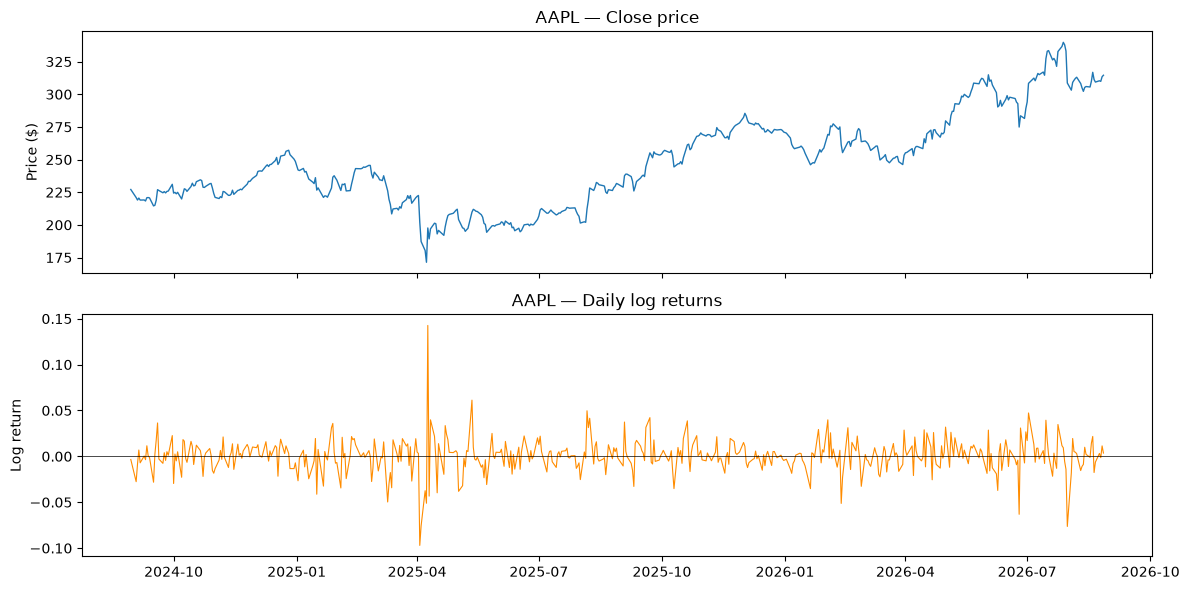

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df.index, df["Close"], linewidth=1)
axes[0].set_title(f"{TICKER} — Close price")
axes[0].set_ylabel("Price ($)")

axes[1].plot(df.index, df["log_return"], linewidth=0.8, color="darkorange")
axes[1].set_title(f"{TICKER} — Daily log returns")
axes[1].set_ylabel("Log return")
axes[1].axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

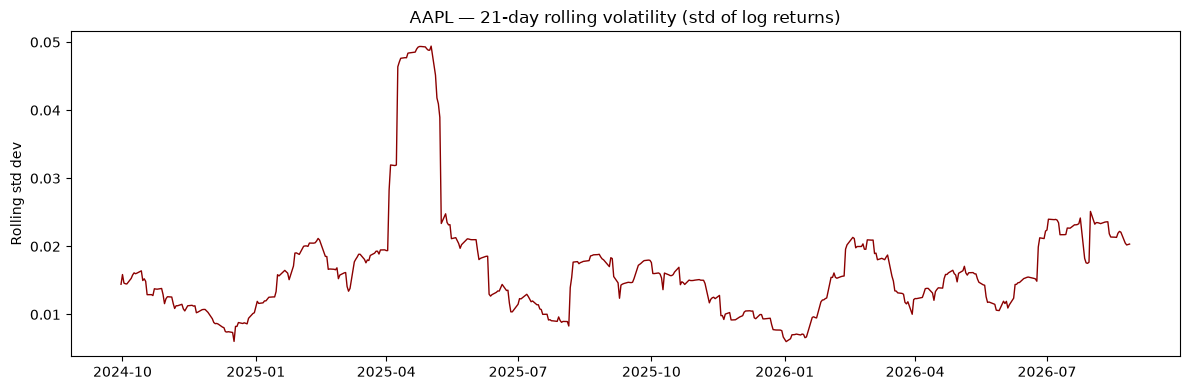

In [3]:
df["rolling_vol_21d"] = df["log_return"].rolling(window=21).std()

plt.figure(figsize=(12, 4))
plt.plot(df.index, df["rolling_vol_21d"], color="darkred", linewidth=1)
plt.title(f"{TICKER} — 21-day rolling volatility (std of log returns)")
plt.ylabel("Rolling std dev")
plt.tight_layout()
plt.show()

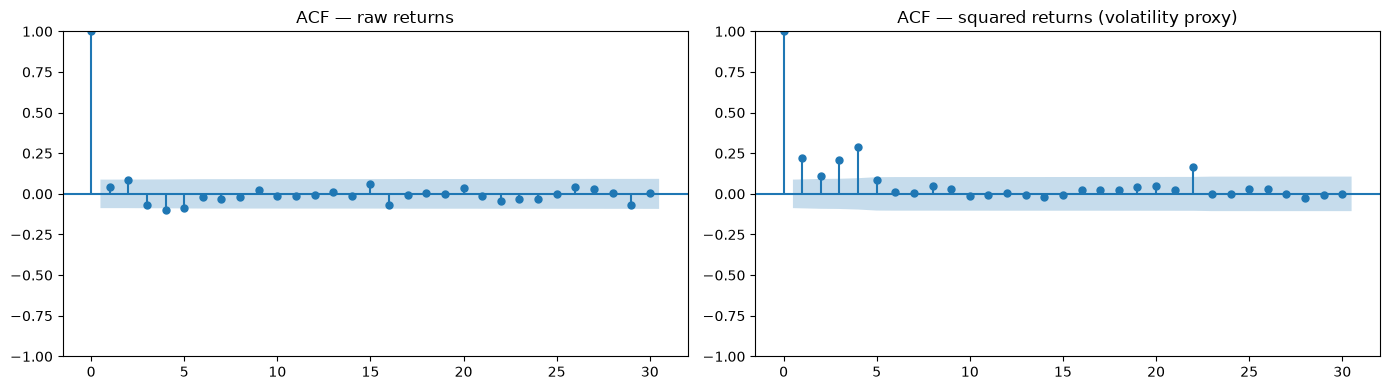

In [4]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df["log_return"], lags=30, ax=axes[0])
axes[0].set_title("ACF — raw returns")

plot_acf(df["log_return"]**2, lags=30, ax=axes[1])
axes[1].set_title("ACF — squared returns (volatility proxy)")

plt.tight_layout()
plt.show()